In [53]:
import json
import csv
import math
import re
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx


In [54]:
gwas = pd.read_csv('data/gwas_catalog.tsv', sep = '\t')
print(gwas.shape)
print(gwas.head())

(540, 10)
  STUDY ACCESSION      DISEASE/TRAIT  CHR_ID    CHR_POS       SNPS  \
0     GCST0000072        Lung cancer      12   25204912  rs1000353   
1     GCST0000074        Lung cancer      17    7620282  rs1000360   
2     GCST0000091       Hypertension       1  230758588  rs1000446   
3     GCST0000033    Body mass index      18   57832184  rs1000170   
4     GCST0000023  Alzheimer disease      19   51215320  rs1000122   

        P-VALUE  OR or BETA MAPPED_GENE  PUBMEDID        DATE  
0  4.250000e-22      1.1550        KRAS  35972328  2011-06-07  
1  6.520000e-10     -0.3357        TP53  29091564  2023-11-25  
2  8.790000e-24      0.0288         AGT  21812865  2018-08-21  
3  1.690000e-17     -0.4371        MC4R  21197835  2013-10-22  
4  2.420000e-18     -0.6003        CD33  32259291  2024-11-18  


In [55]:
gwas['DISEASE/TRAIT'].unique()

array(['Lung cancer', 'Hypertension', 'Body mass index',
       'Alzheimer disease', 'Rheumatoid arthritis', 'Schizophrenia',
       'Colorectal cancer', 'Atrial fibrillation', 'Melanoma',
       'Inflammatory bowel disease', 'Coronary artery disease',
       'Prostate cancer', 'Type 2 diabetes', 'Breast cancer',
       'Parkinson disease'], dtype=object)

In [56]:
no_studies=gwas.groupby('DISEASE/TRAIT')['STUDY ACCESSION'].nunique().reset_index(name='n_studies')
sort_studies = no_studies.sort_values('n_studies', ascending=False)
over3= sort_studies[sort_studies['n_studies']>=3]

n_snps = gwas.groupby('DISEASE/TRAIT')['SNPS'].nunique().reset_index(name='n_snps')
result= over3.merge(n_snps, on='DISEASE/TRAIT') 

result



,DISEASE/TRAIT,n_studies,n_snps
0,Colorectal cancer,12,55
1,Hypertension,11,57
2,Alzheimer disease,10,59
3,Body mass index,10,45
4,Schizophrenia,10,45
5,Lung cancer,9,39
6,Rheumatoid arthritis,8,36
7,Parkinson disease,8,37
8,Melanoma,7,37
9,Type 2 diabetes,6,35


In [57]:
table = gwas.loc[gwas.groupby('CHR_ID')['P-VALUE'].idxmin(),['CHR_ID', 'DISEASE/TRAIT', 'SNPS','P-VALUE']]
chrid = list(table['CHR_ID'])
snpid = list(table['SNPS'])
trait = list(table['DISEASE/TRAIT'])
pvalue = list(table['P-VALUE'])

result={}

for c, s, t, p in zip(chrid, snpid, trait, pvalue):
    result[c] = (s, t, p)

result


{1: ('rs1000329', 'Rheumatoid arthritis', 4.33e-30),
 2: ('rs1000052', 'Coronary artery disease', 4.69e-29),
 3: ('rs1000426', 'Hypertension', 1.93e-30),
 4: ('rs1000138', 'Body mass index', 7.6899999999999995e-28),
 5: ('rs1000233', 'Inflammatory bowel disease', 4.6200000000000004e-27),
 6: ('rs1000326', 'Rheumatoid arthritis', 4.2000000000000004e-29),
 7: ('rs1000494', 'Atrial fibrillation', 2.96e-30),
 8: ('rs1000181', 'Schizophrenia', 1.8999999999999998e-30),
 9: ('rs1000354', 'Lung cancer', 3.74e-30),
 10: ('rs1000478', 'Melanoma', 1.24e-30),
 11: ('rs1000259', 'Prostate cancer', 1.88e-30),
 12: ('rs1000412', 'Hypertension', 1.8499999999999998e-30),
 13: ('rs1000037', 'Breast cancer', 4.11e-30),
 14: ('rs1000190', 'Schizophrenia', 2.6200000000000003e-27),
 15: ('rs1000487', 'Atrial fibrillation', 1.41e-29),
 16: ('rs1000143', 'Body mass index', 6.76e-30),
 17: ('rs1000430', 'Hypertension', 1.9499999999999998e-30),
 18: ('rs1000159', 'Body mass index', 8.360000000000001e-29),
 19: 

In [58]:
#partir em windows de 1 milhão
#mapear snps à window
#mapear chr aos snps
#mapear disease trait aos snps

gwas['window_start']= (gwas['CHR_POS']//1000000)*1000000
gwas['window_end'] = gwas['window_start']+ 1000000

result = gwas.groupby(['CHR_ID','window_start','window_end'])
window = result['DISEASE/TRAIT'].nunique().reset_index()
window.columns = ['chr','window_start','window_end','n_traits']

window_sorted = window.sort_values(by=['n_traits', 'chr', 'window_start'], ascending=[False, True, True],key=lambda col: col.astype(int) if col.name == 'chr' else col)

top5 = window_sorted.head(5)

top5_tuples = list(top5.itertuples(index=False, name=None))

top5_tuples



[(7, 140000000, 141000000, 3),
 (9, 21000000, 22000000, 3),
 (1, 113000000, 114000000, 2),
 (1, 230000000, 231000000, 2),
 (2, 47000000, 48000000, 2)]

In [59]:
data = pd.read_csv('data/ppi_network.tsv', sep = '\t')
data.head()

,protein_a,protein_b,combined_score,experimental_score
0,FADD,CDC37,405,331
1,PIK3R1,STAT3,459,371
2,BRCA1,MLH1,820,770
3,BRCA1,CHEK2,890,840
4,EP300,CREBBP,960,940


In [60]:
def buildPPINetwork(filepath, min_score = 400):
    data = pd.read_csv(filepath, sep = '\t')

    G = nx.Graph()
    
    #dataframe to top5_tuples
    data_tuple = data[data['combined_score']>= min_score].itertuples(index=False)
    for row in data_tuple:
        G.add_edge(
            row.protein_a,
            row.protein_b,
            weight=row.combined_score
        )

    return G

#test
G = buildPPINetwork('data/ppi_network.tsv')
print((G.number_of_nodes()), G.number_of_edges())


87 160


In [61]:
def topHubs(graph):
     
    hubs = sorted(G.degree(), key=lambda x: x[1], reverse=True)

    return hubs[:10]

hubs = topHubs(G)
print("Top 10 network hubs:")
for protein, deg in hubs:
    print(f"  {protein}: {deg} interaction partners")

Top 10 network hubs:
  TP53: 12 interaction partners
  CDK2: 9 interaction partners
  CASP9: 8 interaction partners
  GRB2: 8 interaction partners
  PIK3R1: 7 interaction partners
  EGFR: 7 interaction partners
  KRAS: 7 interaction partners
  PIK3CA: 7 interaction partners
  BRCA1: 6 interaction partners
  MDM2: 6 interaction partners


In [62]:
def networkComponents(graph):
    components = list(nx.connected_components(graph))
    sizes = sorted([len(c) for c in components], reverse=True)
    
    return (len(components), sizes[0], sizes)

# Test
print (networkComponents(G))


(1, 87, [87])


In [63]:
def shortestInteractionPath(graph, protein_a, protein_b):
    """
    Return the shortest unweighted path between two proteins.

    If no path exists, return None.
    """
    try:
        return nx.shortest_path(graph, source=protein_a, target=protein_b)
    except nx.NetworkXNoPath:
        return None
    except nx.NodeNotFound:
        return None
    
path = shortestInteractionPath(G, "TP53", "EGFR")
print (path)

['TP53', 'EGFR']


Breast cancer module: 6 proteins, 7 interactions
Modularity score: 0.0275


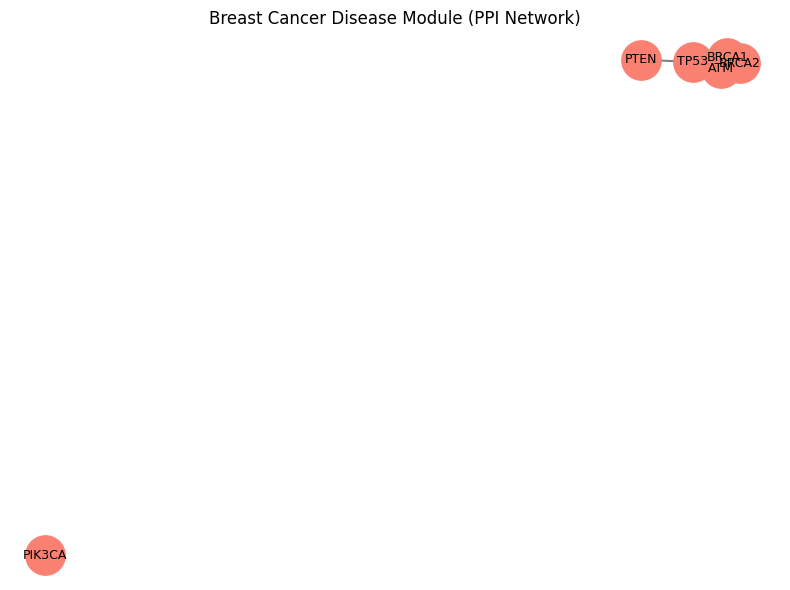

In [68]:

from networkx.algorithms import community as nx_comm
import matplotlib.pyplot as plt


def breastCancerModule(graph, clinvar_filepath):
    """
    Extracts the breast cancer disease module from the PPI network.
    Returns (subgraph, modularity_score), or (subgraph, None) if too small.
    """
    # 1. Parse ClinVar JSON and extract breast cancer genes
    with open(clinvar_filepath, 'r') as f:
        data = json.load(f)

    result = data['result']
    uids = result['uids']

    breast_cancer_genes = set()
    for uid in uids:
        variant = result[uid]
        significance = variant['clinical_significance']['description']
        conditions = [c['name'] for c in variant['conditions']]
        genes = [g['symbol'] for g in variant['genes']]

        if significance in ('Pathogenic', 'Likely pathogenic'):
            for cond in conditions:
                if 'breast cancer' in cond.lower():
                    breast_cancer_genes.update(genes)
                    break

    # 2. Build induced subgraph
    nodes_in_graph = [g for g in breast_cancer_genes if g in graph.nodes]
    subgraph = graph.subgraph(nodes_in_graph).copy()

    # 3. Check if subgraph is large enough
    if subgraph.number_of_nodes() < 2 or subgraph.number_of_edges() == 0:
        return (subgraph, None)

    # 4. Detect communities and compute modularity
    communities = list(nx_comm.greedy_modularity_communities(subgraph))
    mod_score = nx_comm.modularity(subgraph, communities)

    return (subgraph, mod_score)


# Test
subG, mod = breastCancerModule(G, 'data/clinvar_variants.json')
print(f"Breast cancer module: {subG.number_of_nodes()} proteins, {subG.number_of_edges()} interactions")
if mod is not None:
    print(f"Modularity score: {mod:.4f}")
else:
    print("Module too small for community detection.")

# Visualise the subgraph
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)
nx.draw_networkx(subG, pos=pos, ax=ax,
                 node_color='salmon', node_size=800,
                 font_size=9, edge_color='gray', width=1.5)
ax.set_title("Breast Cancer Disease Module (PPI Network)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('breast_cancer_module.png', dpi=150)
plt.show()